##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import keras
import keras_hub #provides pretrained models like: ViT, Bert
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
#Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset('vit_base_patch16_224_imagenet')
#ViT-B16 model pre-trained on the ImageNet 1k dataset with image resolution of 224x224

In [3]:
#Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
model = keras_hub.models.ViTImageClassifier.from_preset('vit_base_patch16_224_imagenet')
#ViT-B16 model pre-trained on the ImageNet 1k dataset with image resolution of 224x224

In [21]:
#Load the images
import requests
from PIL import Image
from io import BytesIO

image_urls = [
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/ipod.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/teapot.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/cup.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/envelope.jpeg",
    "https://raw.githubusercontent.com/shadenalsuhayan/arti560-computer-vision-labs/main/lab03-image-classification-vision-transformer-vit/images/icecream.jpeg"
]

expected_labels = [
    "iPod",
    "teapot",
    "cup",
    "envelope",
    "ice cream"
]

images = []
for url in image_urls:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img = np.array(img)
    images.append(img)

processed_list = []
for img in images:
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    img_tensor = tf.expand_dims(img_tensor, axis=0)
    processed_img = preprocessor(img_tensor) #apply preprocessor
    processed_list.append(processed_img[0])

processed_images = tf.stack(processed_list, axis=0)

classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_names = requests.get(classes_url).text.splitlines()

#Predict classes
predictions = model.predict(processed_images)
predicted_indices = np.argmax(predictions, axis=1)

predicted_labels = [class_names[i] for i in predicted_indices]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [29]:
print("Image File\tPredicted Label\t\tTrue Label\tCorrect?")
print("_"*65)

results = []

for i in range(len(images)):
    pred = predicted_labels[i]
    true = expected_labels[i]
    correct = "Yes" if true.lower() in pred.lower() or pred.lower() in true.lower() else "No"
    print(f"{image_urls[i].split('/')[-1]}\t{pred}\t\t{true}\t\t{correct}")
    results.append([image_urls[i].split('/')[-1], pred, true, correct])

Image File	Predicted Label		True Label	Correct?
_________________________________________________________________
ipod.jpeg	nematode		iPod		No
teapot.jpeg	matchstick		teapot		No
cup.jpeg	nematode		cup		No
envelope.jpeg	nematode		envelope		No
icecream.jpeg	matchstick		ice cream		No


Image 1 shape: (740, 740, 3), dtype: uint8


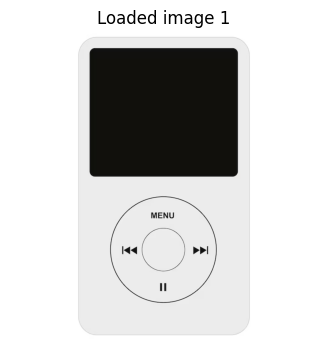

Image 2 shape: (1500, 1500, 3), dtype: uint8


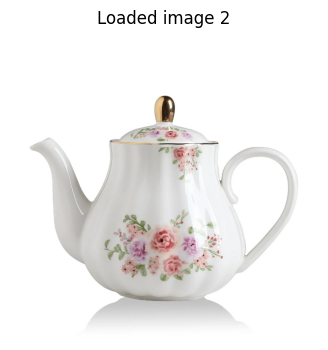

Image 3 shape: (1200, 1200, 3), dtype: uint8


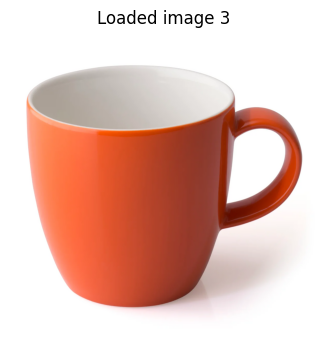

Image 4 shape: (1000, 1000, 3), dtype: uint8


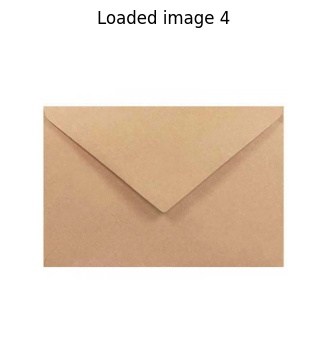

Image 5 shape: (1110, 740, 3), dtype: uint8


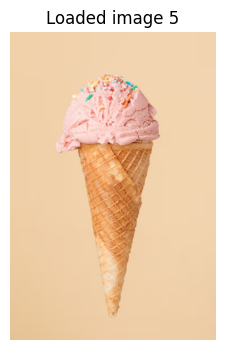

In [30]:
for i, img in enumerate(images):
    print(f"Image {i+1} shape: {img.shape}, dtype: {img.dtype}")

    plt.figure(figsize=(4,4))
    plt.imshow(img.astype("uint8"))
    plt.title(f"Loaded image {i+1}")
    plt.axis("off")
    plt.show()

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
|              | ______          |                                | ______            |
